In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import pickle

from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split,GridSearchCV

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.metrics import classification_report,ConfusionMatrixDisplay,roc_curve,auc,roc_auc_score,accuracy_score


import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder


In [2]:
import pandas as pd

df = pd.read_csv(
    r"c:\Users\dhana\OneDrive\Desktop\CV projects\investments_VC.csv",
    encoding="latin1"
)
df

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,NaN,London,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,TX,Dallas,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.columns

Index(['permalink', 'name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

In [4]:
df.info

<bound method DataFrame.info of                              permalink                name  \
0                /organization/waywire            #waywire   
1      /organization/tv-communications  &TV Communications   
2        /organization/rock-your-paper   'Rock' Your Paper   
3       /organization/in-touch-network   (In)Touch Network   
4       /organization/r-ranch-and-mine  -R- Ranch and Mine   
...                                ...                 ...   
54289                              NaN                 NaN   
54290                              NaN                 NaN   
54291                              NaN                 NaN   
54292                              NaN                 NaN   
54293                              NaN                 NaN   

                        homepage_url  \
0             http://www.waywire.com   
1              http://enjoyandtv.com   
2       http://www.rockyourpaper.org   
3      http://www.InTouchNetwork.com   
4                      

In [5]:
df.dtypes

permalink                object
name                     object
homepage_url             object
category_list            object
 market                  object
 funding_total_usd       object
status                   object
country_code             object
state_code               object
region                   object
city                     object
funding_rounds          float64
founded_at               object
founded_month            object
founded_quarter          object
founded_year            float64
first_funding_at         object
last_funding_at          object
seed                    float64
venture                 float64
equity_crowdfunding     float64
undisclosed             float64
convertible_note        float64
debt_financing          float64
angel                   float64
grant                   float64
private_equity          float64
post_ipo_equity         float64
post_ipo_debt           float64
secondary_market        float64
product_crowdfunding    float64
round_A 

In [6]:
df.isna().sum()

permalink                4856
name                     4857
homepage_url             8305
category_list            8817
 market                  8824
 funding_total_usd       4856
status                   6170
country_code            10129
state_code              24133
region                  10129
city                    10972
funding_rounds           4856
founded_at              15740
founded_month           15812
founded_quarter         15812
founded_year            15812
first_funding_at         4856
last_funding_at          4856
seed                     4856
venture                  4856
equity_crowdfunding      4856
undisclosed              4856
convertible_note         4856
debt_financing           4856
angel                    4856
grant                    4856
private_equity           4856
post_ipo_equity          4856
post_ipo_debt            4856
secondary_market         4856
product_crowdfunding     4856
round_A                  4856
round_B                  4856
round_C   

In [7]:
df.columns

Index(['permalink', 'name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

In [8]:
df.columns = df.columns.str.strip()

df = df[['market',
         'funding_total_usd',
         'status',
         'funding_rounds',
         "country_code",
         'seed',
         'venture',
         'debt_financing',
         'angel']]

In [34]:
df

,market,funding_total_usd,status,funding_rounds,country_code,seed,venture,debt_financing,angel
0,News,1750000,acquired,1.0,USA,1750000.0,0.0,0.0,0.0
1,Games,4000000,operating,2.0,USA,0.0,4000000.0,0.0,0.0
2,Publishing,40000,operating,1.0,EST,40000.0,0.0,0.0,0.0
3,Electronics,1500000,operating,1.0,GBR,1500000.0,0.0,0.0,0.0
4,Tourism,60000,operating,2.0,USA,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
49432,Biotechnology,2686600,operating,1.0,AUT,0.0,2686600.0,0.0,0.0
49433,Education,320000,operating,1.0,GBR,320000.0,0.0,0.0,0.0
49434,Enterprise Software,1587301,operating,1.0,CHN,0.0,1587301.0,0.0,0.0
49435,Web Development,97398,operating,5.0,HRV,71525.0,0.0,0.0,0.0


In [9]:
df.dropna(inplace=True)

In [10]:
df["status"].unique()

array(['acquired', 'operating', 'closed'], dtype=object)

In [11]:
df['funding_total_usd'] = (
    df['funding_total_usd']
    .astype(str)
    .str.replace(',', '')
    .str.replace('-', '0')
)

df['funding_total_usd'] = pd.to_numeric(
    df['funding_total_usd'],
    errors='coerce'
)

df.dropna(inplace=True)

print(df.head())
print(df.shape)

          market  funding_total_usd     status  funding_rounds country_code  \
0          News             1750000   acquired             1.0          USA   
1         Games             4000000  operating             2.0          USA   
2    Publishing               40000  operating             1.0          EST   
3   Electronics             1500000  operating             1.0          GBR   
4       Tourism               60000  operating             2.0          USA   

        seed    venture  debt_financing  angel  
0  1750000.0        0.0             0.0    0.0  
1        0.0  4000000.0             0.0    0.0  
2    40000.0        0.0             0.0    0.0  
3  1500000.0        0.0             0.0    0.0  
4        0.0        0.0             0.0    0.0  
(40477, 9)


In [12]:
df.dtypes

market                object
funding_total_usd      int64
status                object
funding_rounds       float64
country_code          object
seed                 float64
venture              float64
debt_financing       float64
angel                float64
dtype: object

# **Funding Distribution Histogram**

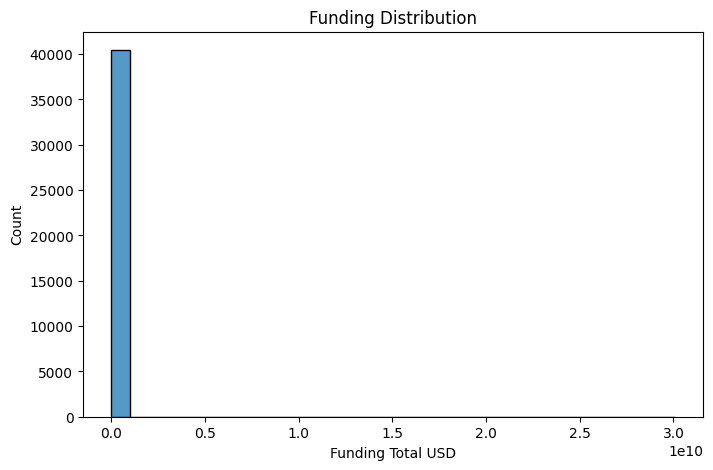

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df["funding_total_usd"], bins=30)

plt.title("Funding Distribution")
plt.xlabel("Funding Total USD")

plt.show()

# **Market vs Funding**

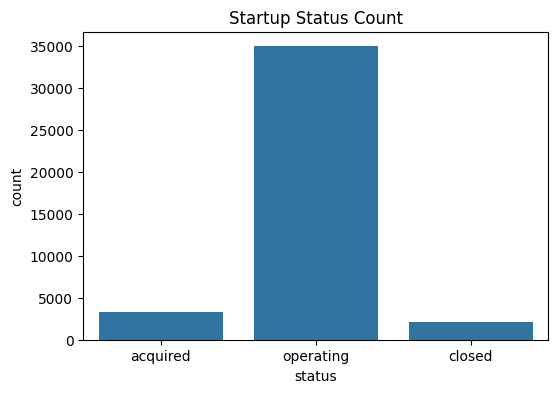

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="status",
    data=df
)

plt.title("Startup Status Count")

plt.show()

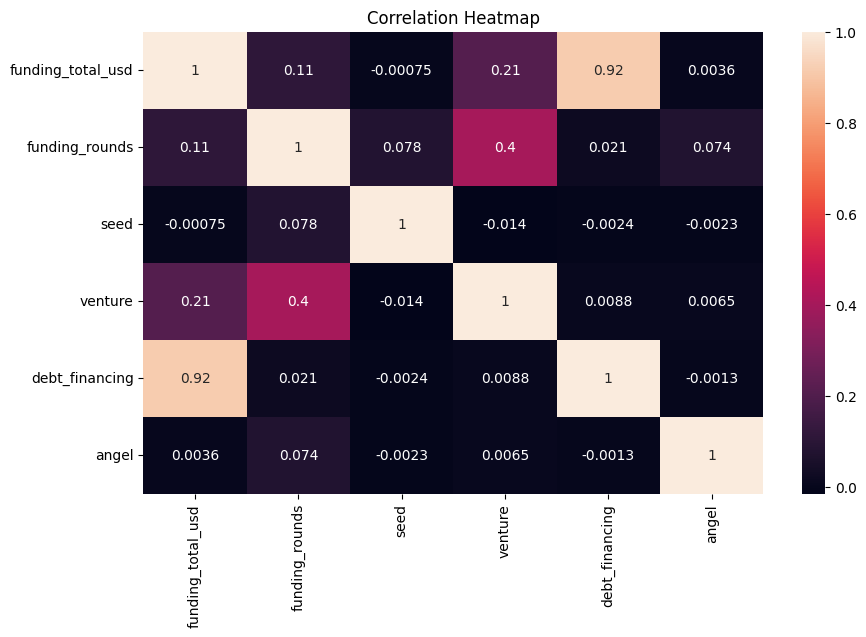

In [19]:
numeric_df = df.select_dtypes(include=['int64','float64'])

corr = numeric_df.corr()

plt.figure(figsize=(10,6))

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")

plt.show()

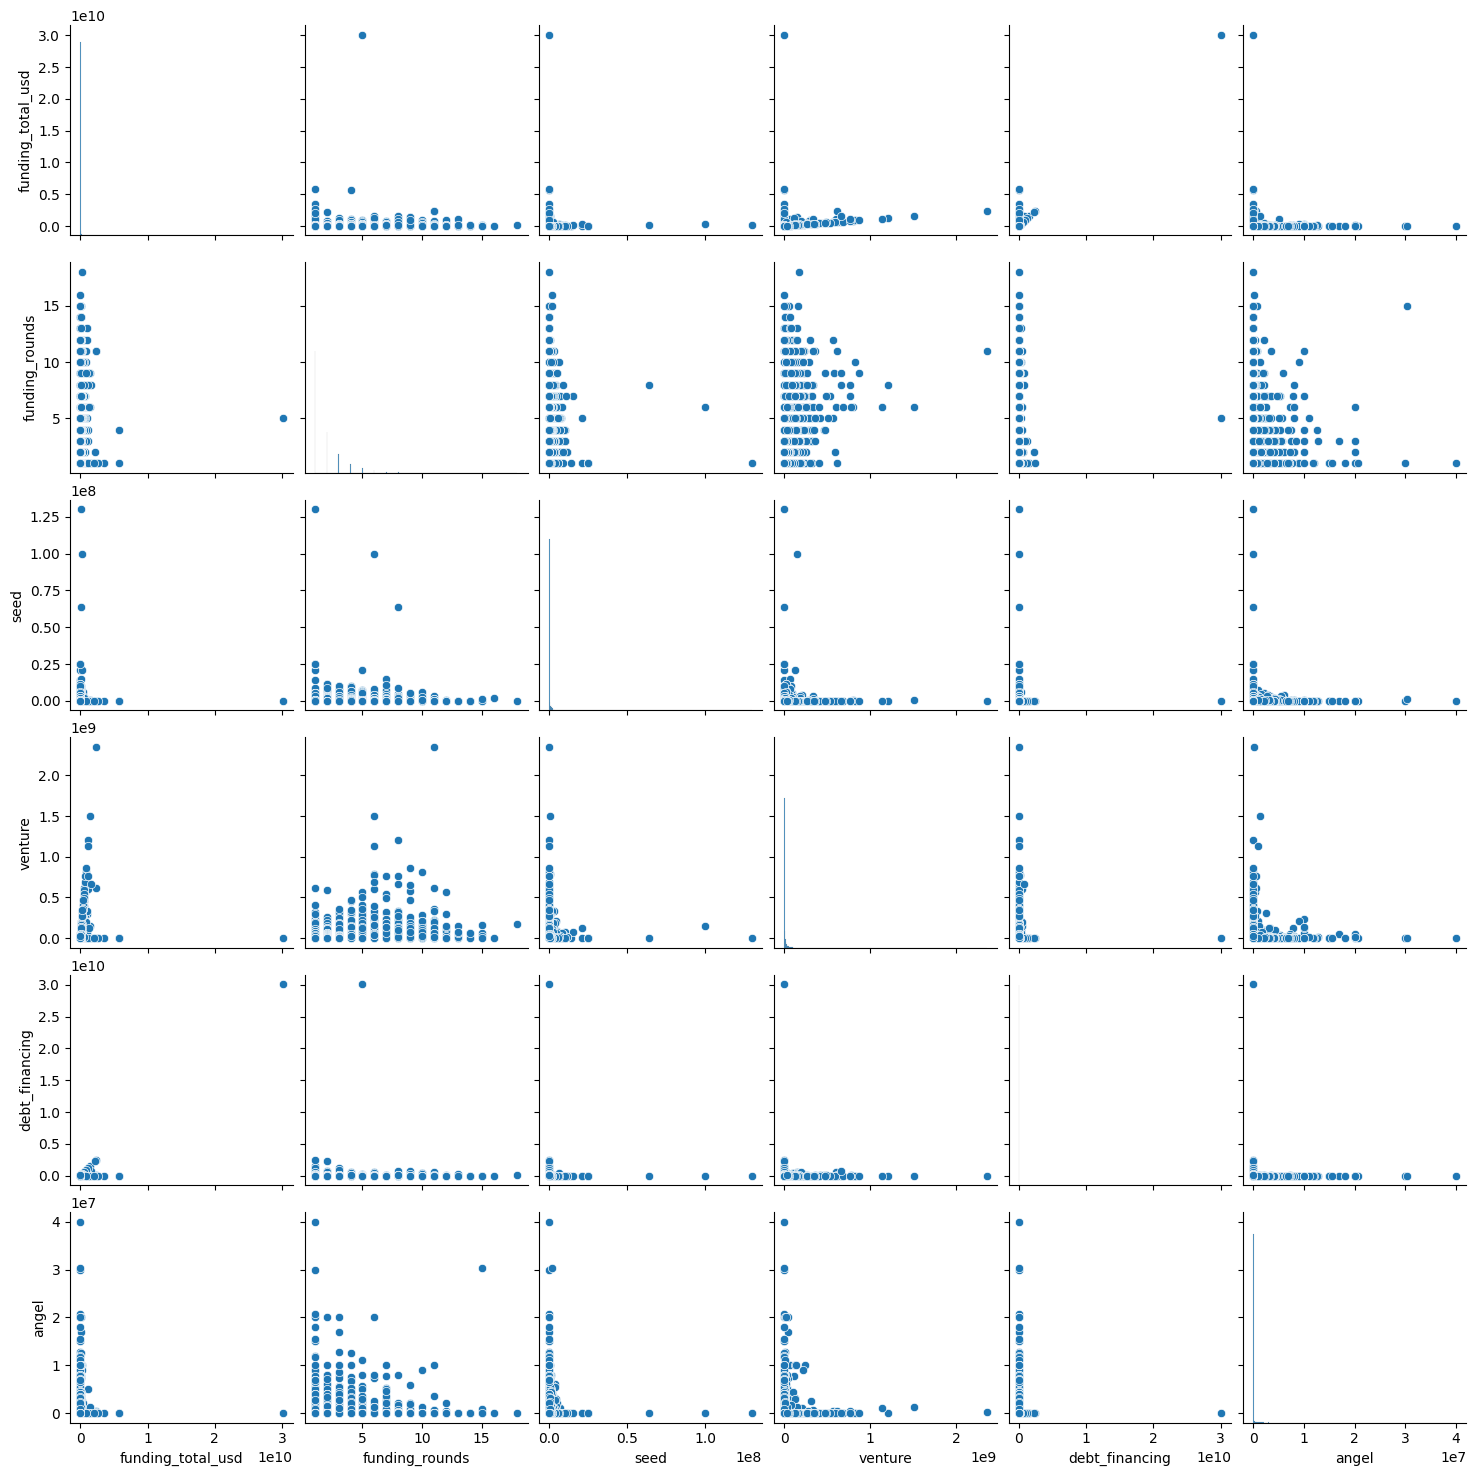

In [20]:
sns.pairplot(
    df.select_dtypes(include=['int64','float64'])
)

plt.show()

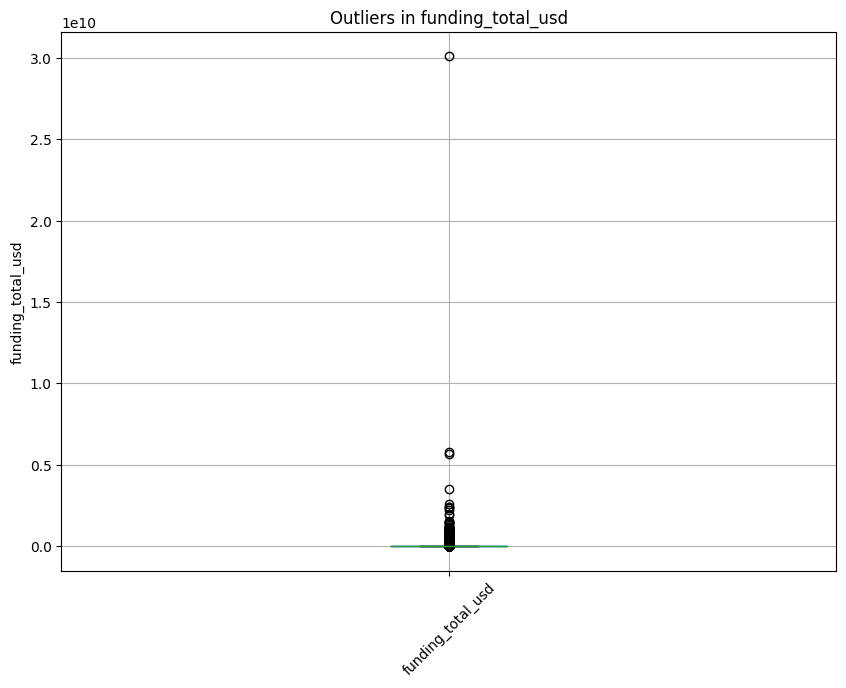

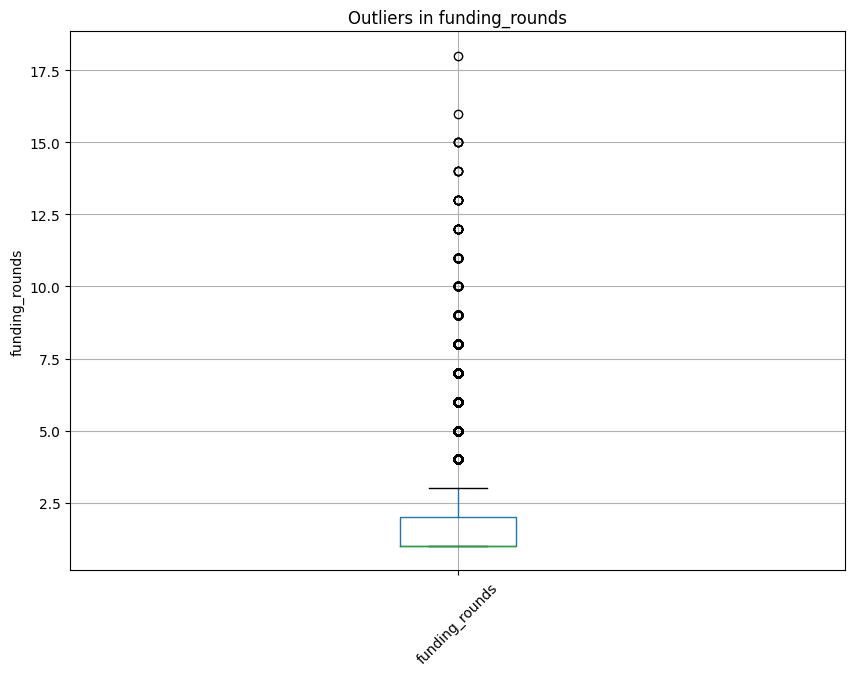

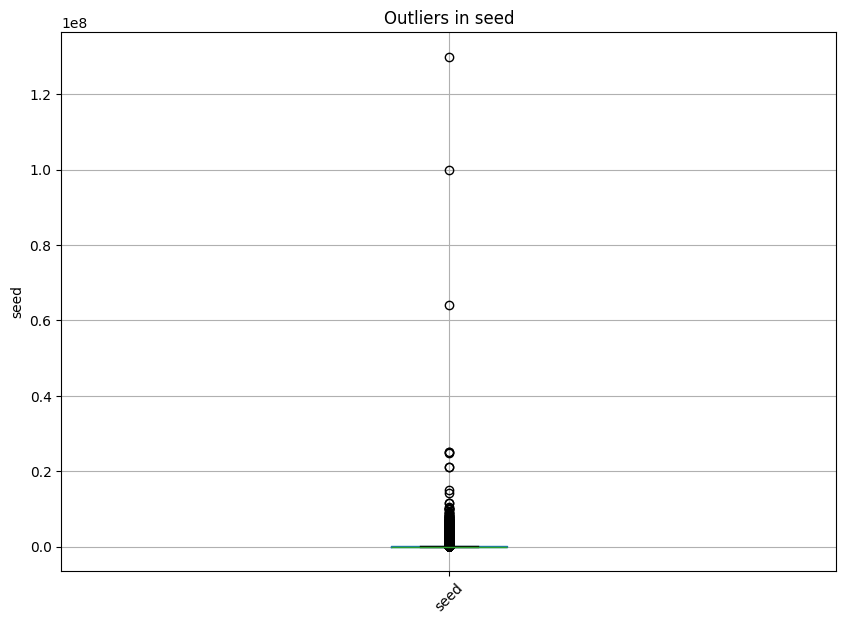

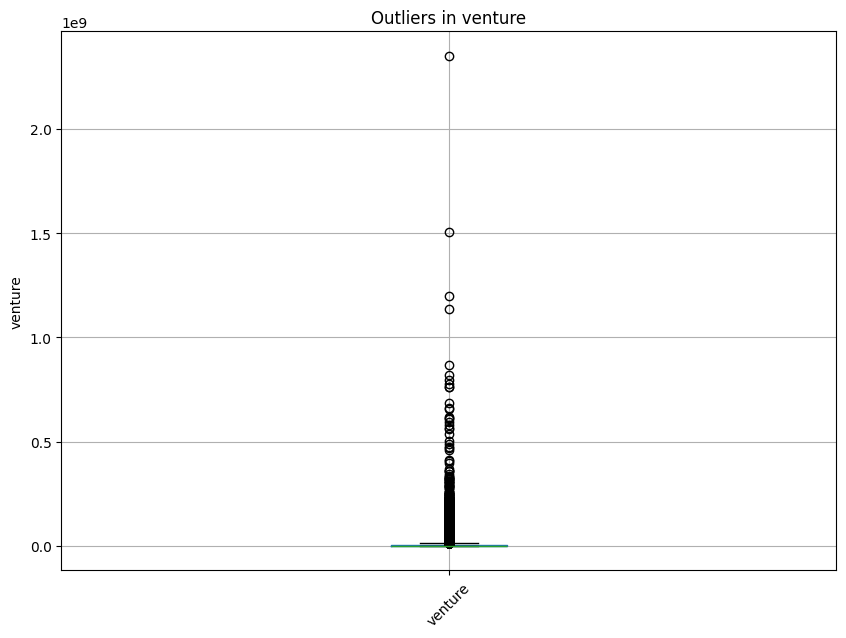

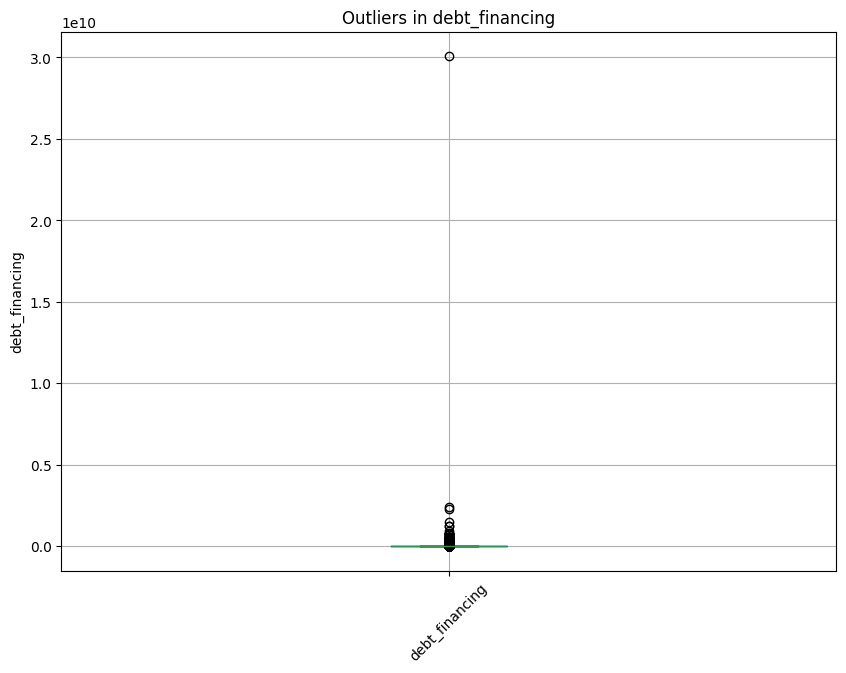

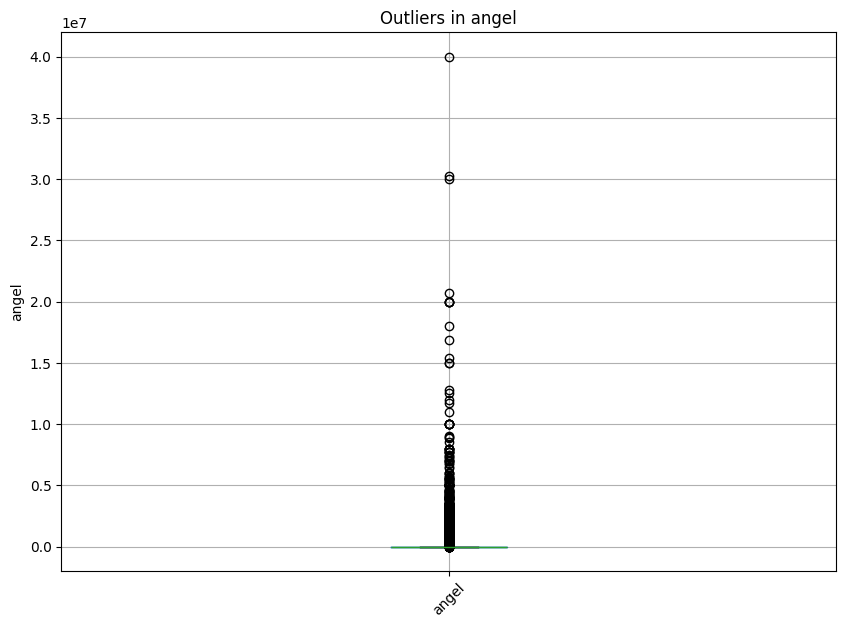

In [33]:
import matplotlib.pyplot as plt

numeric_cols = [
    'funding_total_usd',
    'funding_rounds',
    'seed',
    'venture',
    'debt_financing',
    'angel'
]

for col in numeric_cols:
    plt.figure(figsize=(10,7))
    
    df.boxplot(column=col)
    
    plt.title(f'Outliers in {col}')
    plt.ylabel(col)
    plt.xticks(rotation=45)
    
    plt.show()

In [79]:
le1 = LabelEncoder()
le2 = LabelEncoder()
le3 = LabelEncoder()
le4 = LabelEncoder()

df['market'] = le1.fit_transform(df['market'])
df['status'] = le2.fit_transform(df['status'])
df['country_code'] = le3.fit_transform(df['country_code'])

In [81]:
x = df.drop('status', axis=1)
y = df['status']

In [82]:
from sklearn.preprocessing import RobustScaler
rs=RobustScaler()
X_s=rs.fit_transform(x)
X_s

array([[ 3.71428571e-01,  4.10925608e-02,  0.00000000e+00, ...,
        -1.66666667e-02,  0.00000000e+00,  0.00000000e+00],
       [-6.66666667e-02,  3.17301743e-01,  1.00000000e+00, ...,
         6.50000000e-01,  0.00000000e+00,  0.00000000e+00],
       [ 5.57142857e-01, -1.68826418e-01,  0.00000000e+00, ...,
        -1.66666667e-02,  0.00000000e+00,  0.00000000e+00],
       ...,
       [-1.69047619e-01,  2.11196906e-02,  0.00000000e+00, ...,
         2.47883500e-01,  0.00000000e+00,  0.00000000e+00],
       [ 9.95238095e-01, -1.61780260e-01,  4.00000000e+00, ...,
        -1.66666667e-02,  0.00000000e+00,  0.00000000e+00],
       [-1.69047619e-01,  5.35044685e+00,  3.00000000e+00, ...,
         4.65000000e+00,  1.70000000e+07,  0.00000000e+00]],
      shape=(40477, 8))

In [83]:
X_train,X_test,y_train,y_test=train_test_split(X_s,y,test_size=0.3,random_state=1)

In [84]:
X_train.shape,X_test.shape

((28333, 8), (12144, 8))

In [85]:
y_train.shape,y_test.shape

((28333,), (12144,))

In [86]:
k=KNeighborsClassifier(n_neighbors=5)
s=SVC(kernel='rbf')
g=GaussianNB()
d=DecisionTreeClassifier(criterion='entropy')
r=RandomForestClassifier(random_state=1)
a=AdaBoostClassifier()
x=XGBClassifier()
gr=GradientBoostingClassifier()
lists1=[]
l=[k,s,g,d,r,a,x,gr]
for i in l:
  print(i)
  i.fit(X_train,y_train)
  y_pred=i.predict(X_test)
  lists1.append(accuracy_score(y_test,y_pred)*100)
  print(accuracy_score(y_test,y_pred)*100)


  # print(classification_report(y_test,y_pred))

KNeighborsClassifier()
84.082674571805
SVC()
85.96014492753623
GaussianNB()
84.88965744400528
DecisionTreeClassifier(criterion='entropy')
76.7868906455863
RandomForestClassifier(random_state=1)
83.86857707509881
AdaBoostClassifier()
85.96014492753623
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree

In [87]:
data=pd.DataFrame(lists1,index=['KNN','SVC','NB','DECISIONTREE','RANDOMFOREST','ADABOOST','XGB','GRADIENT'],columns=['default parameters'])
data

,default parameters
KNN,84.082675
SVC,85.960145
NB,84.889657
DECISIONTREE,76.786891
RANDOMFOREST,83.868577
ADABOOST,85.960145
XGB,85.828393
GRADIENT,85.927207


In [88]:
# # KNeighbors
# p={'n_neighbors':[1,3,5,7,9],'weights':['uniform','distance'],'algorithm':['auto', 'ball_tree', 'kd_tree', 'brute']}
# clf=GridSearchCV(k,p,cv=5,scoring='accuracy')
# clf.fit(X_train,y_train)
# print(clf.best_params_)

In [89]:
# #SVC
# p={'kernel':['linear','poly','rbf']}
# clf=GridSearchCV(s,p,cv=5,scoring='accuracy')
# clf.fit(X_train,y_train)
# print(clf.best_params_)

In [90]:
# # Decisiontree
# p={'criterion':['gini', 'entropy'],'max_depth':[2,3,4,5,6],'random_state':[1,2,3,4,5]}
# clf=GridSearchCV(d,p,cv=5,scoring='accuracy')
# clf.fit(X_train,y_train)
# print(clf.best_params_)

In [91]:
# #Randomforsest
# p={'n_estimators':[100,150,200],'max_depth':[1,2,3,4,5],'random_state':[1,2,3,4,5]}
# clf=GridSearchCV(r,p,cv=5,scoring='accuracy')
# clf.fit(X_train,y_train)
# print(clf.best_params_)

In [92]:
# #AdaBoost
# p={'n_estimators':[100,150,200],'random_state':[1,2,3,4,5]}
# clf=GridSearchCV(a,p,cv=5,scoring='accuracy')
# clf.fit(X_train,y_train)
# print(clf.best_params_)

In [93]:
# #gradient
# p={'n_estimators':[100,150,200],'max_depth':[1,2,3,4,5],'random_state':[1,2,3,4,5]}
# clf=GridSearchCV(gr,p,cv=5,scoring='accuracy')
# clf.fit(X_train,y_train)
# print(clf.best_params_)

In [94]:
# #XGB
# p={'n_estimators':[100,150,200],'max_depth':[1,2,3,4,5],'random_state':[1,2,3,4,5]}
# clf=GridSearchCV(x,p,cv=5,scoring='accuracy')
# clf.fit(X_train,y_train)
# print(clf.best_params_)

In [95]:
k1=KNeighborsClassifier(n_neighbors=9,algorithm='auto',weights='uniform')
s1=SVC(kernel='rbf')
d1=DecisionTreeClassifier(max_depth=2,random_state=1,criterion='gini')
r1=RandomForestClassifier(random_state=1,n_estimators=100,max_depth=1)
a1=AdaBoostClassifier(n_estimators=100,random_state=1)
x1=XGBClassifier(random_state=1,n_estimators=100)
gr1=GradientBoostingClassifier(max_depth=2,n_estimators=150,random_state=1)
lists1=[]
l1=[k1,s1,d1,r1,a1,x1,gr1]
for i in l1:
  print(i)
  i.fit(X_train,y_train)
  y_pred1=i.predict(X_test)
  lists1.append(accuracy_score(y_test,y_pred1)*100)
  print(accuracy_score(y_test,y_pred1)*100)
  # print(classification_report(y_test,y_pred1))  

KNeighborsClassifier(n_neighbors=9)
85.28491436100131
SVC()
85.96014492753623
DecisionTreeClassifier(max_depth=2, random_state=1)
85.96014492753623
RandomForestClassifier(max_depth=1, random_state=1)
85.96014492753623
AdaBoostClassifier(n_estimators=100, random_state=1)
85.96014492753623
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
       

In [96]:
data1=pd.DataFrame(lists1,index=['KNN','SVC','DECISIONTREE','RANDOMFOREST','ADABOOST','XGB','GRADIENT'],columns=['hyperparameter '])
data1

,hyperparameter
KNN,85.284914
SVC,85.960145
DECISIONTREE,85.960145
RANDOMFOREST,85.960145
ADABOOST,85.960145
XGB,85.828393
GRADIENT,85.951910


In [97]:
print(df['status'].value_counts())

status
2    34978
0     3353
1     2146
Name: count, dtype: int64


In [98]:
x = df.drop('status', axis=1)
y = df['status']

In [99]:
from imblearn.over_sampling import SMOTE

o = SMOTE(random_state=1)
X_os, y_os = o.fit_resample(x, y)

In [100]:
y.value_counts()

status
2    34978
0     3353
1     2146
Name: count, dtype: int64

In [101]:
y_os.value_counts()

status
0    34978
2    34978
1    34978
Name: count, dtype: int64

In [102]:
X_o=rs.fit_transform(X_os)
X_o

array([[ 3.38842975e-01, -2.40255241e-02,  0.00000000e+00, ...,
        -1.04078853e-01,  0.00000000e+00,  0.00000000e+00],
       [-1.68044077e-01,  1.92204193e-01,  1.00000000e+00, ...,
         3.40365592e-01,  0.00000000e+00,  0.00000000e+00],
       [ 5.53719008e-01, -1.88360109e-01,  0.00000000e+00, ...,
        -1.04078853e-01,  0.00000000e+00,  0.00000000e+00],
       ...,
       [-7.05234160e-01,  2.92707285e-01,  0.00000000e+00, ...,
         4.56565039e-01,  0.00000000e+00,  0.00000000e+00],
       [ 3.85674931e-02, -8.84812003e-02,  0.00000000e+00, ...,
        -1.04078853e-01,  1.07930071e+06,  0.00000000e+00],
       [ 8.01652893e-01,  7.68816772e-01,  6.36850336e-01, ...,
         1.00703226e+00,  0.00000000e+00,  0.00000000e+00]],
      shape=(104934, 8))

In [103]:
X_train1,X_test1,y_train1,y_test1=train_test_split(X_o,y_os,test_size=0.3,random_state=1)

overfitting

In [104]:
k_o=KNeighborsClassifier(n_neighbors=3)
s_o=SVC(kernel='rbf')
g_o=GaussianNB()
d_o=DecisionTreeClassifier(criterion='entropy')
r_o=RandomForestClassifier(random_state=1)
a_o=AdaBoostClassifier()
x_o=XGBClassifier()
gr_o=GradientBoostingClassifier()
lists2=[]
l_o=[k_o,s_o,g_o,d_o,r_o,a_o,x_o,gr_o]
for i in l_o:
  print(i)
  i.fit(X_train1,y_train1)
  y_pred_o=i.predict(X_test1)
  lists2.append(accuracy_score(y_test1,y_pred_o)*100)
  print(accuracy_score(y_test1,y_pred_o)*100)
  # print(classification_report(y_test1,y_pred_o))

KNeighborsClassifier(n_neighbors=3)
65.68406340332264
SVC()
33.29627394301325
GaussianNB()
32.85473777834249
DecisionTreeClassifier(criterion='entropy')
75.20409135669134
RandomForestClassifier(random_state=1)
80.88053111400527
AdaBoostClassifier()
55.033194625329564
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, 

In [105]:
data2=pd.DataFrame(lists2,index=['KNN','SVC','NB','DECISIONTREE','RANDOMFOREST','ADABOOST','XGB','GRADIENT'],columns=['oversampling'])
data2

,oversampling
KNN,65.684063
SVC,33.296274
NB,32.854738
DECISIONTREE,75.204091
RANDOMFOREST,80.880531
ADABOOST,55.033195
XGB,74.105016
GRADIENT,64.203805


with parameter

In [106]:
k2=KNeighborsClassifier(n_neighbors=9,algorithm='brute',weights='uniform')
s2=SVC(kernel='rbf')
d2=DecisionTreeClassifier(criterion='gini',max_depth=2,random_state=1,splitter='random')
r2=RandomForestClassifier(random_state=1,n_estimators=100,max_depth=1)
a2=AdaBoostClassifier(n_estimators=100,random_state=1)
x2=XGBClassifier(random_state=1,n_estimators=100)
gr2=GradientBoostingClassifier(max_depth=2,n_estimators=150,random_state=1)
lists3=[]
l2=[k2,s2,d2,r2,a2,x2,gr2]
for i in l2:
  print(i)
  i.fit(X_train1,y_train1)
  y_pred2=i.predict(X_test1)
  lists3.append(accuracy_score(y_test1,y_pred2)*100)
  print(accuracy_score(y_test1,y_pred2)*100)
  # print(classification_report(y_test1,y_pred2))

KNeighborsClassifier(algorithm='brute', n_neighbors=9)
63.6955624027191
SVC()
33.29627394301325
DecisionTreeClassifier(max_depth=2, random_state=1, splitter='random')
38.24529081033004
RandomForestClassifier(max_depth=1, random_state=1)
49.07722118102983
AdaBoostClassifier(n_estimators=100, random_state=1)
56.46898129030209
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_str

In [107]:
data3=pd.DataFrame(lists3,index=['KNN','SVC','DECISIONTREE','RANDOMFOREST','ADABOOST','XGB','GRADIENT'],columns=['oversamplig-hyperparameter '])
data3

,oversamplig-hyperparameter
KNN,63.695562
SVC,33.296274
DECISIONTREE,38.245291
RANDOMFOREST,49.077221
ADABOOST,56.468981
XGB,74.105016
GRADIENT,62.869667


In [108]:
x = df.drop('status', axis=1)
y = df['status']

In [109]:
u=RandomUnderSampler(random_state=1)
X_us,y_us=u.fit_resample(x,y)

In [110]:
y.value_counts()

status
2    34978
0     3353
1     2146
Name: count, dtype: int64

In [111]:
y_us.value_counts()

status
0    2146
1    2146
2    2146
Name: count, dtype: int64

In [112]:
X_u=rs.fit_transform(X_us)
X_u

array([[ 9.62877030e-01,  5.78711867e-01,  1.00000000e+00, ...,
         7.79977778e-01,  0.00000000e+00,  0.00000000e+00],
       [ 3.52668213e-01,  4.82259889e-02,  0.00000000e+00, ...,
         1.68866667e-01,  0.00000000e+00,  0.00000000e+00],
       [ 6.19489559e-01, -1.23277202e-01,  1.00000000e+00, ...,
        -1.08911111e-01,  2.50000000e+05,  4.71880000e+05],
       ...,
       [-6.82134571e-01,  7.71615823e-01,  0.00000000e+00, ...,
         1.00220000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 5.77726218e-01, -1.44677967e-01,  0.00000000e+00, ...,
        -1.08911111e-01,  0.00000000e+00,  0.00000000e+00],
       [-2.34338747e-01, -1.39855368e-01,  0.00000000e+00, ...,
        -1.08911111e-01,  0.00000000e+00,  5.50000000e+05]],
      shape=(6438, 8))

In [113]:
X_train2,X_test2,y_train2,y_test2=train_test_split(X_u,y_us,test_size=0.3,random_state=1)

undersampling

In [114]:
k_u=KNeighborsClassifier(n_neighbors=5)
s_u=SVC(kernel='rbf')
g_u=GaussianNB()
d_u=DecisionTreeClassifier(criterion='entropy')
r_u=RandomForestClassifier(random_state=1)
a_u=AdaBoostClassifier()
x_u=XGBClassifier()
gr_u=GradientBoostingClassifier()
lists4=[]
l_u=[k_u,s_u,g_u,d_u,r_u,a_u,x_u,gr_u]
for i in l_u:
  print(i)
  i.fit(X_train2,y_train2)
  y_pred_u=i.predict(X_test2)
  lists4.append(accuracy_score(y_test2,y_pred_u)*100)
  print(accuracy_score(y_test2,y_pred_u)*100)
  # print(classification_report(y_test2,y_pred_u))

KNeighborsClassifier()
43.2712215320911
SVC()
33.126293995859214
GaussianNB()
34.62732919254658
DecisionTreeClassifier(criterion='entropy')
42.028985507246375
RandomForestClassifier(random_state=1)
44.51345755693582
AdaBoostClassifier()
45.75569358178054
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_

In [115]:
data4=pd.DataFrame(lists4,index=['KNN','SVC','NB','DECISIONTREE','RANDOMFOREST','ADABOOST','XGB','GRADIENT'],columns=['undersampling'])
data4

,undersampling
KNN,43.271222
SVC,33.126294
NB,34.627329
DECISIONTREE,42.028986
RANDOMFOREST,44.513458
ADABOOST,45.755694
XGB,48.654244
GRADIENT,51.242236


In [116]:
k3=KNeighborsClassifier(n_neighbors=9,algorithm='brute',weights='distance')
s3=SVC(kernel='rbf')
d3=DecisionTreeClassifier(criterion='gini',max_depth=2,random_state=1,splitter='random')
r3=RandomForestClassifier(random_state=1,n_estimators=100,max_depth=1)
a3=AdaBoostClassifier(n_estimators=100,random_state=1)
x3=XGBClassifier(random_state=1,n_estimators=100)
gr3=GradientBoostingClassifier(max_depth=2,n_estimators=150,random_state=1)
lists5=[]
l3=[k3,s3,d3,r3,a3,x3,gr3]
for i in l3:
  print(i)
  i.fit(X_train2,y_train2)
  y_pred3=i.predict(X_test2)
  lists5.append(accuracy_score(y_test2,y_pred3)*100)
  print(accuracy_score(y_test2,y_pred3)*100)
  # print(classification_report(y_test2,y_pred3))

KNeighborsClassifier(algorithm='brute', n_neighbors=9, weights='distance')
44.099378881987576
SVC()
33.126293995859214
DecisionTreeClassifier(max_depth=2, random_state=1, splitter='random')
37.060041407867494
RandomForestClassifier(max_depth=1, random_state=1)
46.63561076604555
AdaBoostClassifier(n_estimators=100, random_state=1)
46.790890269151134
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_co

In [117]:
data5=pd.DataFrame(lists5,index=['KNN','SVC','DECISIONTREE','RANDOMFOREST','ADABOOST','XGB','GRADIENT'],columns=['undersamplig-hyperparameter '])
data5

,undersamplig-hyperparameter
KNN,44.099379
SVC,33.126294
DECISIONTREE,37.060041
RANDOMFOREST,46.635611
ADABOOST,46.790890
XGB,48.654244
GRADIENT,50.207039


In [118]:
datas=pd.concat([data,data1,data2,data3,data4,data5],axis=1)
datas

,default parameters,hyperparameter,oversampling,oversamplig-hyperparameter,undersampling,undersamplig-hyperparameter
KNN,84.082675,85.284914,65.684063,63.695562,43.271222,44.099379
SVC,85.960145,85.960145,33.296274,33.296274,33.126294,33.126294
NB,84.889657,NaN,32.854738,NaN,34.627329,NaN
DECISIONTREE,76.786891,85.960145,75.204091,38.245291,42.028986,37.060041
RANDOMFOREST,83.868577,85.960145,80.880531,49.077221,44.513458,46.635611
ADABOOST,85.960145,85.960145,55.033195,56.468981,45.755694,46.790890
XGB,85.828393,85.828393,74.105016,74.105016,48.654244,48.654244
GRADIENT,85.927207,85.951910,64.203805,62.869667,51.242236,50.207039


              precision    recall  f1-score   support

           0       0.74      0.70      0.72     10514
           1       0.72      0.72      0.72     10384
           2       0.76      0.81      0.78     10583

    accuracy                           0.74     31481
   macro avg       0.74      0.74      0.74     31481
weighted avg       0.74      0.74      0.74     31481



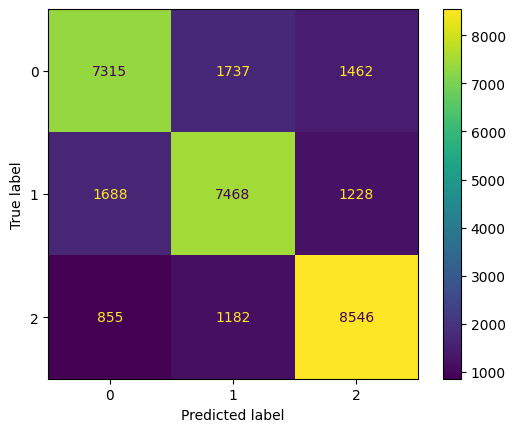

In [119]:
xg=XGBClassifier()
xg.fit(X_train1,y_train1)
y_pred_xg=xg.predict(X_test1)
print(classification_report(y_test1,y_pred_xg))
print(ConfusionMatrixDisplay.from_predictions(y_test1,y_pred_xg))

In [120]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(
    y_test1,
    xg.predict_proba(X_test1),
    multi_class='ovr'
)

print("AUC Score:", auc_score)

AUC Score: 0.8986084910950467


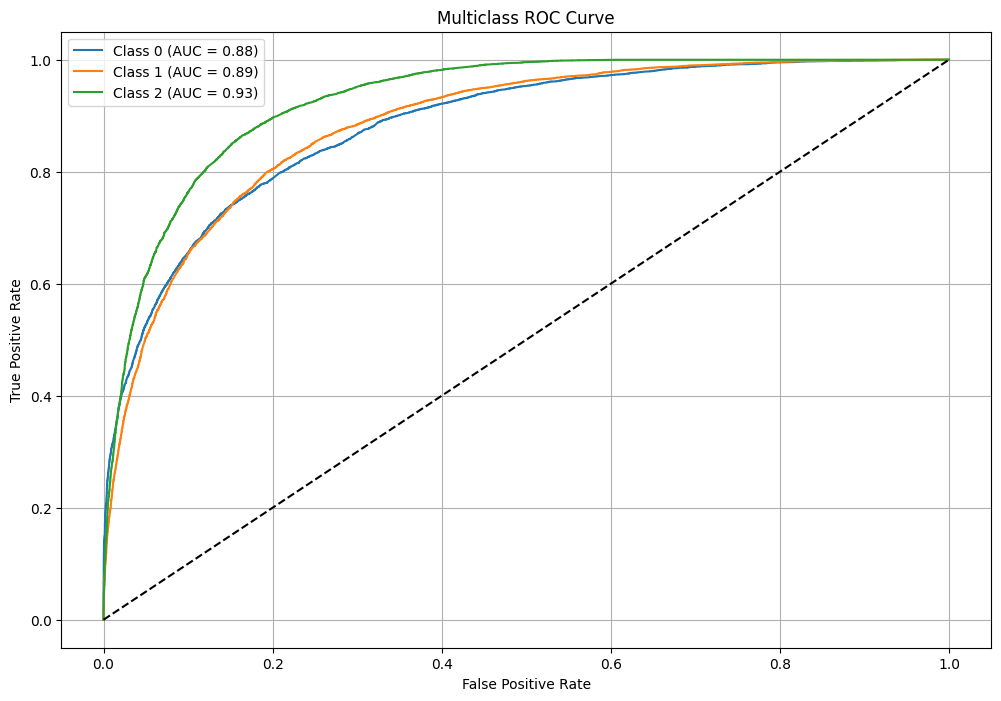

In [121]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Get all unique classes
classes = np.unique(y_test1)

# Convert multiclass to binary
y_test_bin = label_binarize(y_test1, classes=classes)

# Probability predictions
y_score = xg.predict_proba(X_test1)

plt.figure(figsize=(12,8))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'Class {classes[i]} (AUC = {roc_auc:.2f})'
    )

plt.plot([0,1], [0,1], 'k--')

plt.title("Multiclass ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

plt.show()

In [122]:
import pickle

# Save model
pickle.dump(xg, open('investment_model.pkl', 'wb'))

# Save scaler
pickle.dump(rs, open('investment_scaler.pkl', 'wb'))

# Save encoders
pickle.dump(le1, open('market_encoder.pkl', 'wb'))
pickle.dump(le2, open('status_encoder.pkl', 'wb'))
pickle.dump(le3, open('country_code.pkl', 'wb'))

print("Files saved successfully")

Files saved successfully
